<a href="https://colab.research.google.com/github/heewonLEE2/Paper-Implementations/blob/main/CV/ResNet50_Implement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ResNet50 논문 기반 구현**

### 1. GPU 확인 및 라이브러리 임포트

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### 2. ImageNette (ImageNet 10-class subset) 다운로드 및 DataLoader 구성

- 논문 augmentation: RandomResizedCrop(224), HorizontalFlip
- 160px 이미지를 224×224로 resize (논문 기준 입력 크기)

In [2]:
!wget -q https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
!tar -xzf imagenette2-160.tgz

In [3]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('imagenette2-160/train', transform=train_transform)
val_dataset = datasets.ImageFolder('imagenette2-160/val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,
                        num_workers=2, pin_memory=True)

print(f'Classes: {train_dataset.classes}')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Train: 9469, Val: 3925


### 3. Bottleneck Block 구현
- 1×1 (채널 축소) → 3×3 (feature 추출) → 1×1 (채널 확장, ×4)
- Option B: 차원 불일치 시에만 1×1 projection shortcut 적용
- ReLU는 addition 이후에 적용 (논문 Figure 2)

In [8]:
class Bottleneck(nn.Module):
    expansion = 4 # 최종 출력 채널 = planes * 4

    def __init__(self, in_channels, planes, stride=1, downsample=None):
        super().__init__()
        # 1×1: 채널 축소 (e.g. 256 → 64)
        self.conv1 = nn.Conv2d(in_channels, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        # 3×3: spatial feature 추출, stride는 여기서 적용하여 해상도 줄임
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        # 1×1: 채널 확장 (e.g. 64 → 256)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion,
                               kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample # Option B projection shortcut

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out)) # ⚠️ addition 전이므로 ReLU 아직 안함

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity # F(x) + x : residual connection 핵심
        out = self.relu(out)
        return out

### 4. ResNet50 전체 모델 구성
- conv1(7×7, stride 2) → BN → ReLU → MaxPool(3×3, stride 2)
- 4개 Stage: Bottleneck × [3, 4, 6, 3]
- Global Average Pooling → FC(10)
- 가중치 초기화: He initialization (논문 Section 3.4)

In [10]:
class ResNet50(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64

        # ── Initial layers (논문 Table 1: conv1) ──
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ── 4개 Stage (논문 Table 1: conv2_x ~ conv5_x) ──
        self.layer1 = self._make_layer(planes=64,  num_blocks=3, stride=1)  # 56×56
        self.layer2 = self._make_layer(planes=128, num_blocks=4, stride=2)  # 28×28
        self.layer3 = self._make_layer(planes=256, num_blocks=6, stride=2)  # 14×14
        self.layer4 = self._make_layer(planes=512, num_blocks=3, stride=2)  # 7×7

        # ── Classifier ──
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

        self._init_weights()

    def _make_layer(self, planes, num_blocks, stride):
        downsample = None
        # Option B: stride≠1 이거나 채널 수 불일치 시에만 projection
        if stride != 1 or self.in_channels != planes * Bottleneck.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, planes * Bottleneck.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * Bottleneck.expansion)
            )

        layers = [Bottleneck(self.in_channels, planes, stride, downsample)]
        self.in_channels = planes * Bottleneck.expansion # 다음 블록의 입력 채널 갱신

        for _ in range(1, num_blocks):
            layers.append(Bottleneck(self.in_channels, planes))

        return nn.Sequential(*layers)

    def _init_weights(self):
        """논문: He initialization (Kaiming normal)"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))  # 112→56
        x = self.layer1(x)  # 56×56
        x = self.layer2(x)  # 28×28
        x = self.layer3(x)  # 14×14
        x = self.layer4(x)  # 7×7
        x = self.avgpool(x)       # 1×1
        x = torch.flatten(x, 1)   # (B, 2048)
        x = self.fc(x)            # (B, 10)
        return x

### 5. 모델 생성 및 학습 설정
- 논문: SGD(momentum=0.9, weight_decay=1e-4), lr=0.1
- Colab 5 epoch 기준으로 lr=0.01, StepLR 적용

In [11]:
model = ResNet50(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')  # ~23.5M (fc가 10 class라 원래보다 약간 적음)

Total parameters: 23,528,522


### 6. 학습 및 평가 루프
- 매 epoch마다 train loss/acc, val loss/acc, 현재 lr 출력

In [12]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

# ── 학습 실행 ──
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
NUM_EPOCHS = 5

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'LR: {scheduler.get_last_lr()[0]:.6f}')

Epoch [1/5] Train Loss: 3.1039 Acc: 0.1496 | Val Loss: 2.1321 Acc: 0.2041 | LR: 0.010000
Epoch [2/5] Train Loss: 2.0531 Acc: 0.2726 | Val Loss: 1.8521 Acc: 0.3345 | LR: 0.001000
Epoch [3/5] Train Loss: 1.8078 Acc: 0.3816 | Val Loss: 1.8270 Acc: 0.4189 | LR: 0.001000
Epoch [4/5] Train Loss: 1.7559 Acc: 0.3995 | Val Loss: 1.7249 Acc: 0.4520 | LR: 0.000100
Epoch [5/5] Train Loss: 1.7239 Acc: 0.4037 | Val Loss: 1.6772 Acc: 0.4555 | LR: 0.000100


### 7. Loss / Accuracy 시각화

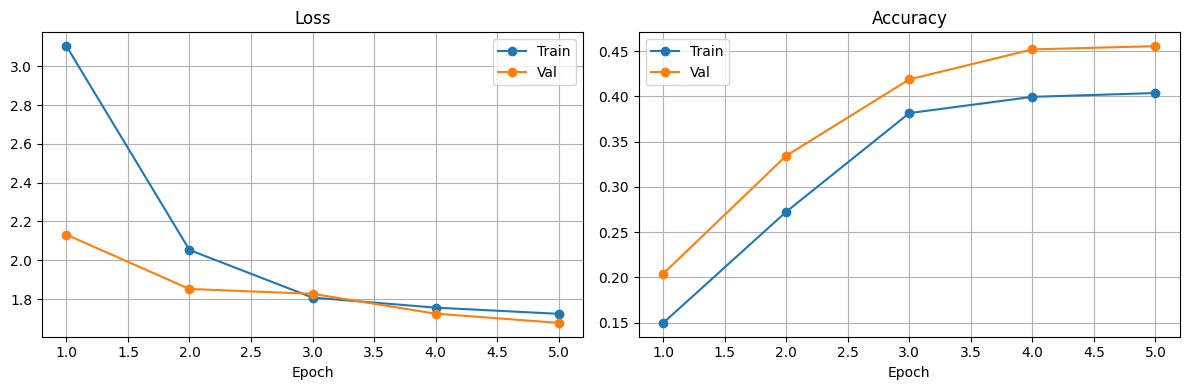

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history['train_loss'], 'o-', label='Train')
ax1.plot(epochs, history['val_loss'], 'o-', label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True)

ax2.plot(epochs, history['train_acc'], 'o-', label='Train')
ax2.plot(epochs, history['val_acc'], 'o-', label='Val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()